# Оценка наивного прогноза доходности

Ноутбук воспроизводимо загружает проверенный обработанный снимок, строит нулевой прогноз доходности следующего торгового дня и фиксирует baseline-метрики отдельно для train и validation. Final test не передаётся модели и не участвует в расчётах.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.contracts import BPS_FACTOR  # noqa: E402
from evaluation.loading import load_processed_snapshot  # noqa: E402
from evaluation.metrics import calculate_metrics  # noqa: E402
from evaluation.pipeline import build_predictions  # noqa: E402
from models.naive import NaiveModel  # noqa: E402

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Проверенный снимок и прогнозы

Загрузчик сверяет обработанный CSV с манифестом до начала оценки. Pipeline передаёт модели только train и validation и формирует стандартную таблицу прогнозов.

In [2]:
snapshot = load_processed_snapshot(PROJECT_ROOT / "data" / "processed")
model = NaiveModel()
predictions = build_predictions(snapshot.dataset, model)

assert set(predictions["split"]) == {"train", "validation"}
assert not predictions["split"].eq("test").any()
assert predictions["model"].eq("naive_zero").all()

predictions.groupby(["split", "ticker"], sort=True).agg(
    observations=("actual_return", "size"),
    first_target_date=("target_date", "min"),
    last_target_date=("target_date", "max"),
)

observations first_target_date last_target_date
split      ticker                                                 
train      AAPL            2515        2006-01-05       2015-12-31
           JPM             2515        2006-01-05       2015-12-31
           SPY             2515        2006-01-05       2015-12-31
           XOM             2515        2006-01-05       2015-12-31
validation AAPL            1006        2016-01-04       2019-12-31
           JPM             1006        2016-01-04       2019-12-31
           SPY             1006        2016-01-04       2019-12-31
           XOM             1006        2016-01-04       2019-12-31

## Метрики baseline

Для каждого тикера и объединённой строки `ALL` рассчитываются MAE и RMSE в базисных пунктах, относительная MAE, вневыборочный R² и directional accuracy. Объединённые метрики рассчитываются непосредственно по наблюдениям.

In [3]:
metrics = calculate_metrics(predictions)

assert set(metrics["split"]) == {"train", "validation"}
assert np.allclose(metrics["rel_mae"], 1.0)
assert np.allclose(metrics["oos_r2"], 0.0)

metric_decimals = {
    "mae_bps": 3,
    "rmse_bps": 3,
    "rel_mae": 3,
    "oos_r2": 3,
    "directional_accuracy": 3,
}
train_metrics = metrics.loc[metrics["split"].eq("train")].reset_index(drop=True)
validation_metrics = metrics.loc[metrics["split"].eq("validation")].reset_index(drop=True)

### Train: описательная диагностика

In [4]:
train_metrics.round(metric_decimals)

,split,ticker,model,observations,mae_bps,rmse_bps,rel_mae,oos_r2,directional_accuracy
0,train,AAPL,naive_zero,2515,153.112,216.386,1.0,0.0,0.002
1,train,JPM,naive_zero,2515,165.232,274.434,1.0,0.0,0.005
2,train,SPY,naive_zero,2515,82.882,130.184,1.0,0.0,0.003
3,train,XOM,naive_zero,2515,105.932,158.964,1.0,0.0,0.005
4,train,ALL,naive_zero,10060,126.789,202.703,1.0,0.0,0.004


### Validation: ориентир для сравнения моделей

In [5]:
validation_metrics.round(metric_decimals)

,split,ticker,model,observations,mae_bps,rmse_bps,rel_mae,oos_r2,directional_accuracy
0,validation,AAPL,naive_zero,1006,106.326,153.878,1.0,0.0,0.002
1,validation,JPM,naive_zero,1006,91.878,130.354,1.0,0.0,0.006
2,validation,SPY,naive_zero,1006,54.834,81.386,1.0,0.0,0.004
3,validation,XOM,naive_zero,1006,83.367,113.807,1.0,0.0,0.004
4,validation,ALL,naive_zero,4024,84.101,122.726,1.0,0.0,0.004


## Распределения ошибок

Для нулевого прогноза ошибка равна фактической доходности. Гистограммы позволяют сравнить масштаб и форму ошибок между выборками и активами, не смешивая train с validation.

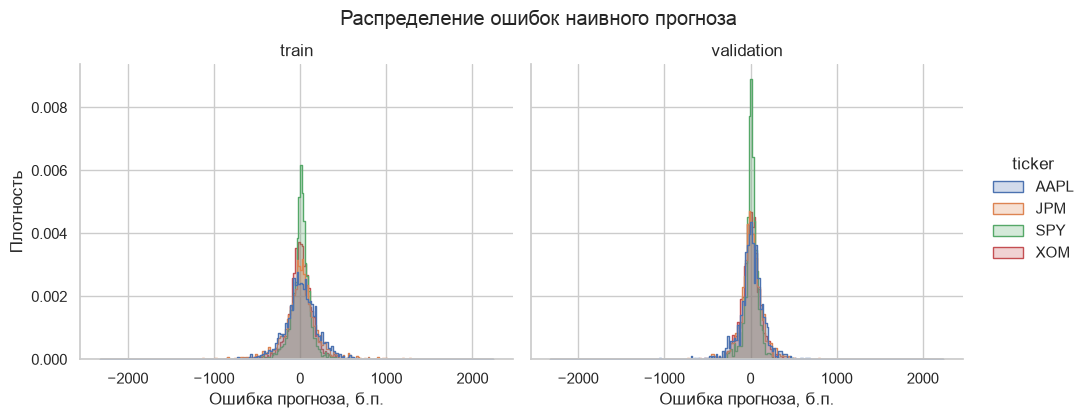

In [6]:
errors = predictions.assign(
    error_bps=(predictions["actual_return"] - predictions["predicted_return"]) * BPS_FACTOR
)
grid = sns.displot(
    data=errors,
    x="error_bps",
    hue="ticker",
    col="split",
    kind="hist",
    element="step",
    stat="density",
    common_norm=False,
    height=4,
    aspect=1.25,
)
grid.set_axis_labels("Ошибка прогноза, б.п.", "Плотность")
grid.set_titles("{col_name}")
grid.figure.suptitle("Распределение ошибок наивного прогноза", y=1.04)
plt.show()

## Интерпретация

- Метрики train используются только как описательная диагностика и не являются оценкой обобщающей способности модели.
- Метрики validation являются зафиксированным ориентиром, относительно которого далее будут сравниваться ARIMA, LSTM и ARIMA-LSTM.
- Более высокая волатильность train может приводить к большим абсолютным ошибкам на train, чем на validation. Для нулевого прогноза это отражает различие распределений доходности и само по себе не свидетельствует об утечке данных.
- Directional accuracy наивной модели не имеет содержательной интерпретации: прогноз всегда равен нулю, поэтому `sign(predicted_return) = 0` и совпадение возможно только при точной нулевой доходности.
- Final test остаётся полностью исключённым и будет использован только после завершения выбора моделей и настроек.